## Setup

In [1]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
sys.path.append("..")

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import normaltest, ttest_rel
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display
from src.uid import *

/Users/tzhang04/Desktop/active-passive-alternations/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-26 14:25:56 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-02-26 14:25:56 INFO: Downloading default packages for language: en (English) ...
2026-02-26 14:25:56 INFO: File exists: /Users/tzhang04/stanza_resources/en/default.zip
2026-02-26 14:25:58 INFO: Finished downloading models and saved to /Users/tzhang04/stanza_resources
2026-02-26 14:25:58 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-02-26 14:25:58 INFO: Downloaded file to /Users/tzhang04/stanza_resources/resources.json
2026-02-26 14:25:58 INFO: Loading t

In [3]:
# Configure plot settings

from re import X
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, LogFormatter
from matplotlib import rc
import matplotlib.gridspec as gridspec
import warnings


warnings.filterwarnings("ignore")

#=== Colormaps ===#

factuality_cmap = {
    True: "#7EACB5",
    False: "#BF4646",
}

conversion_cmap = {
    "P to A": "#B7BDF7",
    "A to P": "#576A8F",
    "Both": "#FFF8DE"
}

context_cmap = {
    "document": "#195C9F",
    "sentence": "#F6C28B",
    "documentA to P": "#195C9F",
    "documentP to A": "#328BAE",
    "sentenceA to P": "#F6C28B",
    "sentenceP to A": "#FDE2C4",
    "other": "#2F3D4C"
}

passive_cmap = {
    True: "#1A3263",
    False: "#FAB95B"
}

#=== Metric Names ===#

surprisal_metrics = [
    'surp_mean', # Mean surprisal
    'surp_slor', # SLOR
]

uid_metrics = [
    'uid_std', # Std. of surprisal
    'uid_mad', # mean avg. deviation of surprisal
    'uid_pwd', # Local variance (pairwise euc. distance)
    'uid_range', # Range of surprisal
    # 'uid_slope', # Slope of a linear function fit to surp values
]

surprisal_metrics_formatted = [
    'Mean Surp.',
    '-SLOR',
]

uid_metrics_formatted = [
    'Surp. STD',
    'Surp. MAD',
    'Local Var.',
    'Surp. Range',
    # 'LinReg Slope',
]

metrics = surprisal_metrics + uid_metrics
metrics_formatted = surprisal_metrics_formatted + uid_metrics_formatted

metrics_mapping = dict(zip(metrics, metrics_formatted))
# metrics_cmap = dict(zip([
#     'surp_slor', ''
# ]))

sns.set_palette("Set2")
# sns.set(rc={
#     'axes.facecolor':'#e5d9b6', 
#     'figure.facecolor':'#e5d9b6'
# })
# Font
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": "Times",
})

In [4]:
# Utils
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])
    
def check_conversion(row):
    mapping = {
        "p>a": "P to A",
        "a>p": "A to P"
    }
    if row['conversion'] != 'og':
        return mapping[row['conversion']]
    if row['passive']:
        return 'P to A'
    return 'A to P'

def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs,
              ):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

### Load docs

In [5]:
docs = []
for path in Path("../data").iterdir():
    docs.extend(iter_counterfactual_docs(path))

In [6]:
docs = dict(docs)
docs

{'f::GUM_academic_art::-1::og': ['Aesthetic Appreciation and Spanish Art:',
  'Insights from Eye-Tracking',
  'Claire Bailey-Ross claire.bailey-ross@port.ac.uk University of Portsmouth, United Kingdom',
  'Andrew Beresford a.m.beresford@durham.ac.uk Durham University, United Kingdom',
  'Daniel Smith daniel.smith2@durham.ac.uk Durham University, United Kingdom',
  'Claire Warwick c.l.h.warwick@durham.ac.uk Durham University, United Kingdom',
  'How do people look at and experience art?',
  'Which elements of specific artworks do they focus on?',
  'Do museum labels have an impact on how people look at artworks?',
  'The viewing experience of art is a complex one, involving issues of perception, attention, memory, decision-making, affect, and emotion.',
  'Thus, the time it takes and the ways of visually exploring an artwork can inform about its relevance, interestingness, and even its aesthetic appeal.',
  'This paper describes a collaborative pilot project focusing on a unique collect

## Sentence-level

In [7]:
data_path = "../outputs/cf_word_sentence_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]

In [8]:
_, uid_unit, uid_level, _ = Path(data_path).stem.split("_")
context_lvls = ['sentence', 'document']
plot_suffix = f"_{uid_unit}_{uid_level}"

In [9]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['surp_slor'] *= -1

In [10]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [11]:
uid_df['factual'].value_counts()

factual
f     76880
cf    19528
Name: count, dtype: int64

In [12]:
uid_df.head()

,doc_id,sent_idx,context,sentence,raw_surps,raw_uni_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,doc_name,conv_idx,conversion
0,f::GUM_academic_art::-1::og,0,sentence,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
1,f::GUM_academic_art::-1::og,0,prev1,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
2,f::GUM_academic_art::-1::og,0,prev3,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
3,f::GUM_academic_art::-1::og,0,document,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
4,f::GUM_academic_art::-1::og,0,"sent[-2,+0]",Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og


In [13]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(39040, 19)

In [14]:
cf_comparison = sents_of_interest[sents_of_interest['context'].isin(context_lvls)].drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx', 'context']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] >= len(context_lvls) * 2)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison['conversion'] = cf_comparison.apply(check_conversion, axis=1)
print(cf_comparison.shape)
cf_comparison.head()

(9756, 19)


,doc_name,sent_idx,level_2,doc_id,context,sentence,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,passive
0,GUM_academic_art,8,0,cf::GUM_academic_art::8::a>p,document,Do museum labels have an impact on how people ...,5.596717,-4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,False,8,A to P,True
1,GUM_academic_art,8,1,cf::GUM_academic_art::8::a>p,sentence,Do museum labels have an impact on how people ...,6.867737,-3.166668,5.620751,4.647271,36.979142,20.102325,0.818428,-0.813244,12,False,8,A to P,True
2,GUM_academic_art,8,2,f::GUM_academic_art::-1::og,document,Do museum labels have an impact on how people ...,5.596717,-4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,True,-1,A to P,False
3,GUM_academic_art,8,3,f::GUM_academic_art::-1::og,sentence,Do museum labels have an impact on how people ...,6.867737,-3.166668,5.620751,4.647271,36.979142,20.102325,0.818428,-0.813244,12,True,-1,A to P,False
4,GUM_academic_art,11,4,cf::GUM_academic_art::11::a>p,document,A collaborative pilot project focusing on a un...,8.397016,-2.723669,8.769274,5.802251,204.251054,39.907106,1.044332,-0.015118,19,False,11,A to P,True


In [15]:
print("N factual:", len(cf_comparison['doc_name'].unique()))
cf_comparison['factual'].value_counts()

N factual: 177


factual
False    4878
True     4878
Name: count, dtype: int64

In [16]:
cf_comparison.loc[cf_comparison['factual'], 'conversion'].value_counts()

conversion
A to P    4600
P to A     278
Name: count, dtype: int64

In [17]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

### Counterfactual vs. Factual

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
hue_order = [True, False]
# surp metrics
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=surprisal_metrics,
       var_name='Metric',
       value_name='Value'
       ),
        hue='factual', y='Value', x='Metric', ax=axs[0], palette=factuality_cmap, hue_order=hue_order,
        showfliers=False)
axs[0].set_title(f"Surprisal metrics")
handles, labels = axs[0].get_legend_handles_labels()
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)
axs[0].legend(title="Factual")
# axs[0].get_legend().remove()

# uid metrics
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=uid_metrics,
       var_name='Metric',
       value_name='Value'
       ),
        hue='factual', y='Value', x='Metric', ax=axs[1], palette=factuality_cmap, hue_order=hue_order,
        showfliers=False)
axs[1].set_title(f"UID metrics")
handles, labels = axs[1].get_legend_handles_labels()
# axs[1].legend(title="Factual", bbox_to_anchor=(1.2, 1.0))
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# axs[1].set_xlabel("")
axs[1].get_legend().remove()

# entire plot
plt.suptitle(f"Factual vs. Counterfactual\n(Context={' or '.join(context_lvls)}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
fig.savefig("../plots/fact_cfact_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

Text(0.5, 0.98, 'Factual vs. Counterfactual\n(Context=sentence or document, Unit=word, Level=sentence)')

Error in callback <function _draw_all_if_interactive at 0x1222905e0> (for post_execute), with arguments args (),kwargs {}:


FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'ptmr7t.tfm' in your texmf tree, but could not find it

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'ptmr7t.tfm' in your texmf tree, but could not find it

<Figure size 1050x500 with 2 Axes>

In [ ]:
(cf_comparison.groupby(['doc_name', 'sent_idx'])['context'].count() == 4).mean()

np.float64(1.0)

In [ ]:
get_diff = lambda s: s.diff().iloc[1]
get_diff_flipped = lambda s: -s.diff().iloc[1]
agg_map = dict(zip(metrics, [get_diff] * len(metrics)))
agg_map.update({
    'conversion': lambda s: 'A to P' if 'A to P' in s.unique() else 'P to A',
    'passive': lambda s: s.iloc[0]
})
pw_diffs = (cf_comparison
            .sort_values(by='factual', ascending=False) # Always Counterfactual - Factual, shows shift
            .groupby(['doc_name','sent_idx', 'context'])
            [metrics + ['conversion', 'passive']]
            .aggregate(
                agg_map
                )
            .reset_index())
pw_diffs = pw_diffs[pw_diffs['surp_mean'] != 0]
pw_diffs['context_conversion'] = pw_diffs['context'] + pw_diffs['conversion']
pw_diffs

,doc_name,sent_idx,context,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,passive,context_conversion
2,GUM_academic_art,11,document,0.059805,0.262695,-0.064312,0.029431,0.050490,0.091301,A to P,False,documentA to P
3,GUM_academic_art,11,sentence,-0.062297,0.139277,-0.170160,0.093602,0.091692,0.018778,A to P,False,sentenceA to P
4,GUM_academic_art,16,document,0.094249,0.017944,-0.096467,0.057091,-0.026847,-0.004102,A to P,False,documentA to P
5,GUM_academic_art,16,sentence,0.098738,0.022482,0.105401,0.321354,0.025947,0.070497,A to P,False,sentenceA to P
6,GUM_academic_art,17,document,0.122918,0.319000,0.298469,0.196714,0.004406,0.700489,A to P,False,documentA to P
...,...,...,...,...,...,...,...,...,...,...,...,...
4873,GUM_whow_skittles,52,sentence,0.033435,0.089921,-0.146685,-0.283584,-0.121197,0.017153,A to P,False,sentenceA to P
4874,GUM_whow_skittles,53,document,0.290453,0.374341,0.152971,0.002881,-0.055320,0.827206,A to P,False,documentA to P
4875,GUM_whow_skittles,53,sentence,0.169536,0.252120,0.059595,-0.205700,0.008811,0.663163,A to P,False,sentenceA to P
4876,GUM_whow_skittles,64,document,0.141144,0.186060,-0.085024,-0.047521,0.001996,-0.114559,A to P,False,documentA to P


In [ ]:
(pw_diffs['surp_mean'] == 0).mean()

np.float64(0.0)

In [ ]:
pw_diffs['conversion'].value_counts(normalize=True)

conversion
A to P    0.934317
P to A    0.065683
Name: proportion, dtype: float64

In [ ]:
pw_diffs_resampled = pd.concat([
    pw_diffs[pw_diffs['conversion'] == 'A to P'].sample((pw_diffs['conversion'] == 'P to A').sum(), replace=False),
    pw_diffs[pw_diffs['conversion'] == 'P to A']
])
pw_diffs_resampled['conversion'].value_counts(normalize=True)

conversion
A to P    0.5
P to A    0.5
Name: proportion, dtype: float64

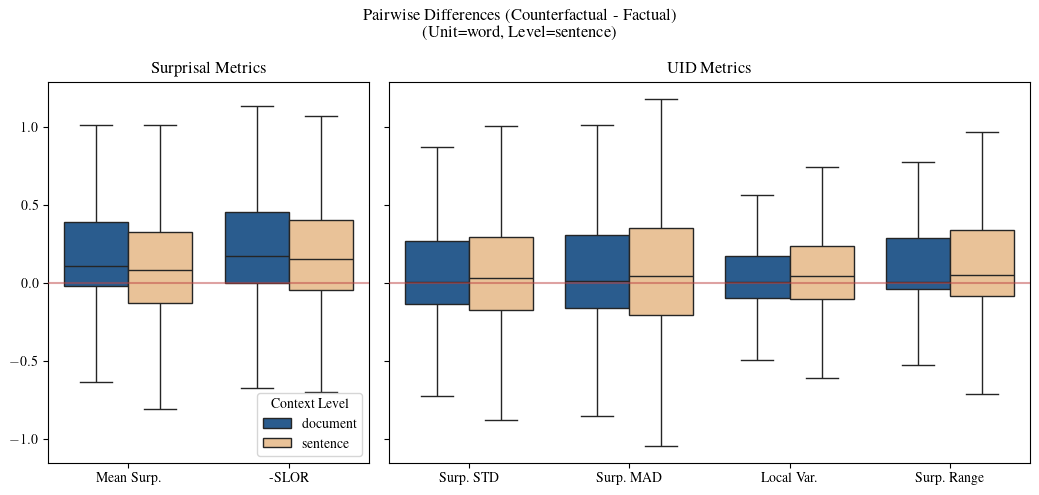

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
# surp metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context'] + surprisal_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context'])), 
            y='value', x='variable', 
            # color=conversion_cmap['Both'],
            hue='context', palette=context_cmap,
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].legend(title="Context Level")
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context'] + uid_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context'])), 
            y='value', x='variable', 
            # color=conversion_cmap['Both'],
            hue='context', palette=context_cmap,
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].get_legend().remove()
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Pairwise Differences (Counterfactual - Factual)\n(Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/pw_diffs_context" + plot_suffix,
            dpi=100, bbox_inches='tight')

In [ ]:
pw_diffs[metrics].median()

surp_mean    0.094909
surp_slor    0.161414
uid_std      0.011526
uid_mad      0.020906
uid_pwd      0.015045
uid_range    0.017290
dtype: float64

In [ ]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [ ]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   P-value |   Observed abs. diff |
|:------------|----------:|---------------------:|
| Mean Surp.  |         0 |                 0.12 |
| -SLOR       |         0 |                 0.18 |
| Surp. STD   |         0 |                 0.09 |
| Surp. MAD   |         0 |                 0.08 |
| Local Var.  |         0 |                 0.06 |
| Surp. Range |         0 |                 0.14 |

In [ ]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_comparison.loc[cf_comparison['factual']]
    cfactuals = cf_comparison.loc[~cf_comparison['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="greater"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [ ]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:------------|---------------:|------------------:|--------------:|-----------------:|
| Mean Surp.  |         282.6  |                 0 |         -7.11 |                1 |
| SLOR        |         226.41 |                 0 |         14.2  |                0 |
| Surp. STD   |         599.59 |                 0 |         -8.37 |                1 |
| Surp. MAD   |         419.25 |                 0 |         -7.06 |                1 |
| Local Var.  |        1796.95 |                 0 |         -6.48 |                1 |
| Surp. Range |         670.11 |                 0 |        -13.59 |                1 |

In [ ]:
print(results
 .round(decimals=2)
 .set_index("Metric")
 .to_latex()
)

\begin{tabular}{lrrrr}
\toprule
 & Normality TS & Normality P-val & Paired-t TS & Paired-t P-val \\
Metric &  &  &  &  \\
\midrule
Mean Surp. & 282.600000 & 0.000000 & -7.110000 & 1.000000 \\
SLOR & 226.410000 & 0.000000 & 14.200000 & 0.000000 \\
Surp. STD & 599.590000 & 0.000000 & -8.370000 & 1.000000 \\
Surp. MAD & 419.250000 & 0.000000 & -7.060000 & 1.000000 \\
Local Var. & 1796.950000 & 0.000000 & -6.480000 & 1.000000 \\
Surp. Range & 670.110000 & 0.000000 & -13.590000 & 1.000000 \\
\bottomrule
\end{tabular}



In [ ]:
factual_passives_sample = cf_comparison[cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
factual_actives_sample = cf_comparison[~cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
pass_vs_act = pd.concat([factual_passives_sample, factual_actives_sample])

In [ ]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(pass_vs_act, 'passive', metric, 10000,
                            test_stat=lambda a, b: b-a,
                            compare_fn=lambda sim, obs: sim >= obs)
    results.append({
        "metric": metric,
        "pval": p_val,
        "observed": obs,
        "simulated": sim
    })
results = pd.DataFrame(results)

Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False


In [ ]:
print(results[['metric', 'observed', 'pval']].to_markdown())

|    | metric    |   observed |   pval |
|---:|:----------|-----------:|-------:|
|  0 | surp_mean |  0.34828   | 0      |
|  1 | surp_slor | -0.50543   | 1      |
|  2 | uid_std   | -0.181755  | 1      |
|  3 | uid_mad   | -0.129262  | 1      |
|  4 | uid_pwd   | -0.0802961 | 0.9994 |
|  5 | uid_range | -0.365734  | 1      |


### Passive vs. Active

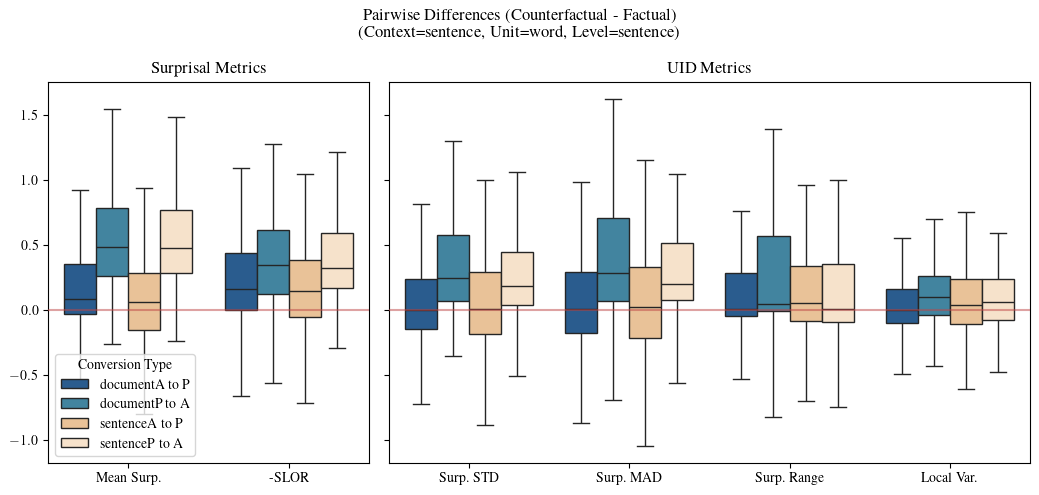

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
# surp metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context_conversion'] + surprisal_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context_conversion'])
             .sort_values('context_conversion')), 
            y='value', x='variable', 
            palette=context_cmap, hue='context_conversion', # Look at context + conversion
            # palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('')
axs[0].set_xlabel('')
# axs[0].legend(title="Context Level : Conversion Type")
axs[0].legend(title="Conversion Type")
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context_conversion'] + uid_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context_conversion'])
             .sort_values('context_conversion')), 
            y='value', x='variable', 
            palette=context_cmap, hue='context_conversion', # Look at context + conversion
            # palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].get_legend().remove()
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Pairwise Differences (Counterfactual - Factual)\n(Context={context_lvl}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/pw_diffs_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

#### Difference in differences between contexts

In [ ]:
pw_diffs.head()

,doc_name,sent_idx,context,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,context_conversion
2,GUM_academic_art,11,document,0.059805,0.262695,-0.064312,0.029431,0.050490,0.091301,A to P,documentA to P
3,GUM_academic_art,11,sentence,-0.062297,0.139277,-0.170160,0.093602,0.091692,0.018778,A to P,sentenceA to P
4,GUM_academic_art,16,document,0.094249,0.017944,-0.096467,0.057091,-0.026847,-0.004102,A to P,documentA to P
5,GUM_academic_art,16,sentence,0.098738,0.022482,0.105401,0.321354,0.025947,0.070497,A to P,sentenceA to P
6,GUM_academic_art,17,document,0.122918,0.319000,0.298469,0.196714,0.004406,0.700489,A to P,documentA to P


In [ ]:
diff_in_pw_diffs = (pw_diffs
    .groupby(['doc_name', 'sent_idx'])
    .filter(lambda g: g.shape[0] >= 2)
    .sort_values(by='context', ascending=False) # Always document - sentence, shows remaining diff
    .groupby(['doc_name','sent_idx'])
    [metrics + ['conversion', 'passive']]
    .aggregate(
        agg_map
        )
    .reset_index())
diff_in_pw_diffs.head(3)

,doc_name,sent_idx,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,passive
0,GUM_academic_art,11,0.122102,0.123418,0.105848,-0.064170,-0.041202,0.072523,A to P,False
1,GUM_academic_art,16,-0.004489,-0.004538,-0.201868,-0.264263,-0.052795,-0.074599,A to P,False
2,GUM_academic_art,17,0.232918,0.235429,0.257614,-0.001112,0.045236,0.743805,A to P,False


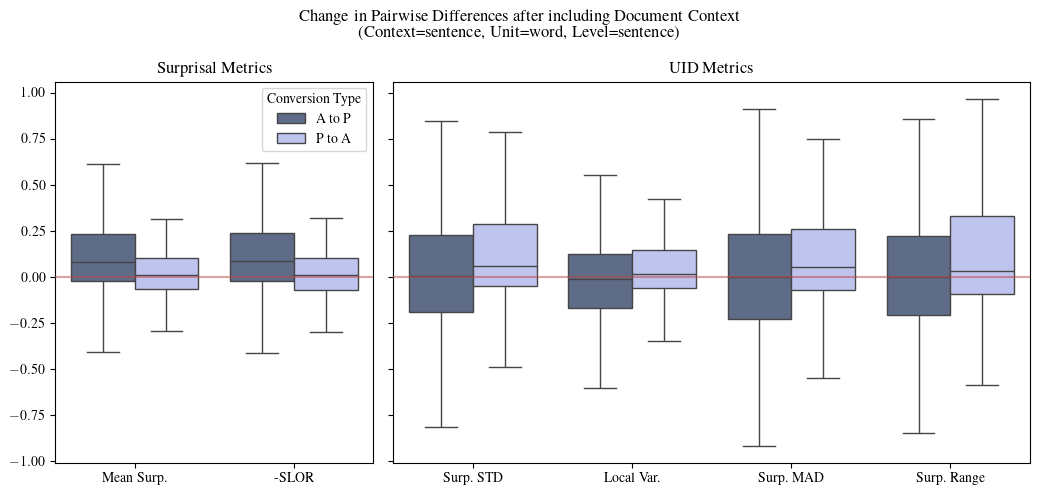

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
# surp metrics
sns.boxplot((diff_in_pw_diffs[['doc_name', 'sent_idx', 'conversion',] + surprisal_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion',])
             .sort_values('conversion')), 
            y='value', x='variable', 
            # palette=context_cmap, hue='context_conversion', # Look at context + conversion
            palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('')
axs[0].set_xlabel('')
# axs[0].legend(title="Context Level : Conversion Type")
axs[0].legend(title="Conversion Type")
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((diff_in_pw_diffs[['doc_name', 'sent_idx', 'conversion',] + uid_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion',])
             .sort_values('conversion')), 
            y='value', x='variable', 
            # palette=context_cmap, hue='context_conversion', # Look at context + conversion
            palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].get_legend().remove()
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Change in Pairwise Differences after including Document Context\n(Context={context_lvl}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/diff_in_pw_diffs_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

For A to P, difference in uniformity metric differences is large after including more context, but difference in uid metric differences is not.
This suggests that the counterfactual Passive sentences are even more surprising but not any less uniform after taking discourse context into account.

For P to A, it's the opposite.
Counterfactual Active sentences don't become more or less surprising given the prior context.
However, they do become even less uniform than before.

What if we look at the differences between sentence surprisal/UID before and after including context *separately* for factual and counterfactual sentences?
- For factual sentences, we expect surprisals to decrease after including context, and potentially for uniformity to increase as well. It'd be surprising to see significant decrease in uniformity or increase in surprisal.
- For counterfactual, we probably expect surprisals increase a lot. In fact, in a void, counterfactual sentences shouldn't be any much surprising than their factual counterparts, whereas with context, they should be a lot more surprising. Same goes for uniformity, but in opposite directions - we expect it to decrease with context.

In [ ]:
context_diffs = (cf_comparison
    .groupby(['doc_name', 'sent_idx', 'factual'])
    .filter(lambda g: g.shape[0] >= 2)
    .sort_values(by='context', ascending=False) # Always document - sentence, shows remaining diff
    .groupby(['doc_name', 'sent_idx', 'factual'])
    [metrics + ['conversion', 'passive']]
    .aggregate(
        agg_map
        )
    .reset_index())
context_diffs_factual = context_diffs[context_diffs['factual']]
context_diffs_counterfactual = context_diffs[~context_diffs['factual']]
context_diffs.head(3)

,doc_name,sent_idx,factual,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,passive
0,GUM_academic_art,8,False,-0.644482,-0.651429,-0.349701,-0.206096,-0.272368,-0.714151,A to P,True
1,GUM_academic_art,8,True,-0.644482,-0.651429,-0.349701,-0.206096,-0.272368,-0.714151,A to P,False
2,GUM_academic_art,11,False,-0.192951,-0.195031,0.072656,0.275180,-0.007837,0.013598,A to P,True


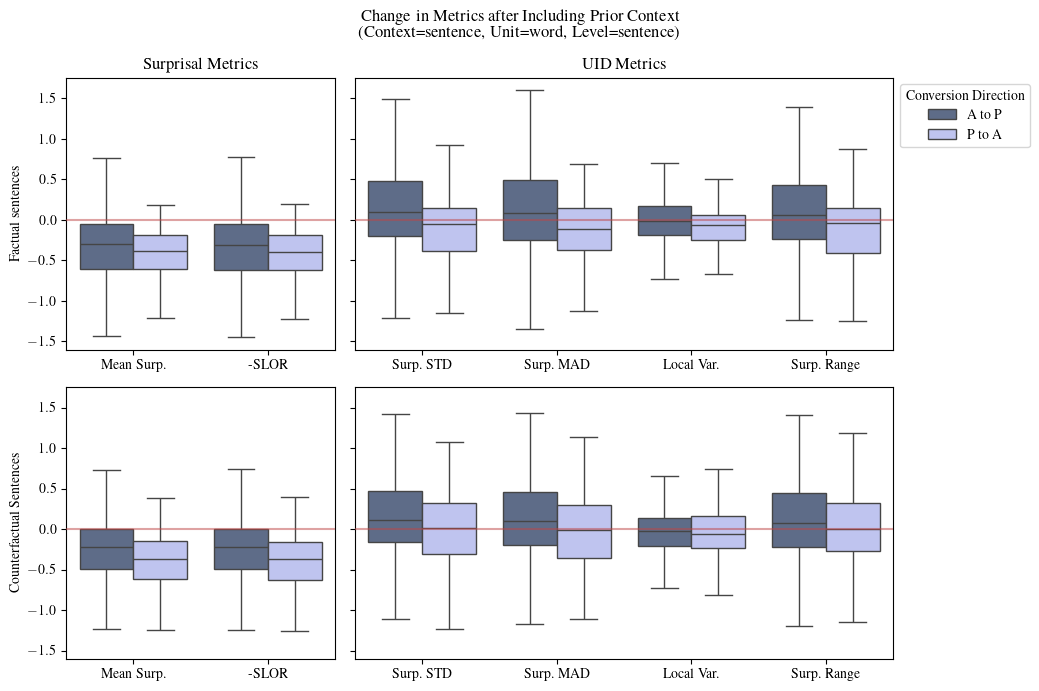

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 7), sharey=True, width_ratios=[1, 2])
axs = [ax for row in axs for ax in row]
cmap, hue_variable = (
    # passive_cmap, 'passive'
    conversion_cmap, 'conversion'
)
id_vars = [hue_variable]
sort_asc = True
## Factual
# surp metrics
sns.boxplot((context_diffs_factual[id_vars + surprisal_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('Factual sentences')
axs[0].set_xlabel('')
# axs[0].legend(title="Context Level : Conversion Type")
axs[0].get_legend().remove()
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((context_diffs_factual[id_vars + uid_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            order=uid_metrics,
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].legend(title="Conversion Direction", bbox_to_anchor=(1,1))
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)

## Counterfactual
# surp metrics
sns.boxplot((context_diffs_counterfactual[id_vars + surprisal_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[2]
            )
axs[2].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[2].set_ylabel('Counterfactual Sentences')
axs[2].set_xlabel('')
# axs[2].legend(title="Context Level : Conversion Type")
axs[2].get_legend().remove()
axs[2].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((context_diffs_counterfactual[id_vars + uid_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            order=uid_metrics,
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[3]
            )
axs[3].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[3].set_ylabel('')
axs[3].set_xlabel('')
axs[3].get_legend().remove()
axs[3].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Change in Metrics after Including Prior Context\n(Context={context_lvl}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/pw_diffs_context_factual_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

This aligns with what we expected.
Surprisal lowers for both counterfactual and factual sentences given more context, but less so for counterfactual.
Uniformity also generally increases for factual sentences, but stays the same/decreases for counterfactual.

There is still an asymmetry based on conversion direction. In the A to P case, both factual and counterfactual sentences seem to increase in uniformity with more prior context.

In [ ]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(context_diffs, 
                            'factual', 
                            metric, 
                            1000,
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        # "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)
results

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


,Metric,P-value,Observed abs. diff
0,Mean Surp.,0.000,0.097408
1,-SLOR,0.000,0.098458
2,Surp. STD,0.532,0.014231
3,Surp. MAD,0.949,0.001667
4,Local Var.,0.584,0.010958
5,Surp. Range,0.224,0.025502


These test results show that the mean changes in uid metrics after adding prior context are not significantly different between factual and counterfactual sentences, but are significant in surprisal metrics.
This suggests that adding context has different effects on surprisal for factual and counterfactual sentences, but the same effect on uniformity.

In [ ]:
results = []
for metric in surprisal_metrics:
    p_to_a = context_diffs[context_diffs['conversion'] == 'P to A']
    a_to_p = context_diffs[context_diffs['conversion'] == 'A to P']
    for data in [p_to_a, a_to_p]:
        obs, sim, p_val = perm_test(data, 
                                'factual', 
                                metric, 
                                1000,
                                test_stat=lambda a, b: a - b,
                                compare_fn=lambda sim, obs: sim >= obs
                                )
        results.append({
            "Metric": metrics_mapping[metric],
            "Conversion": data['conversion'].iloc[0],
            "P-value": p_val,
            "Observed abs. diff": obs,
            # "Simulated abs. diff": sim
        })
results = pd.DataFrame(results)
results

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


,Metric,Conversion,P-value,Observed abs. diff
0,Mean Surp.,P to A,0.544,-0.006517
1,Mean Surp.,A to P,0.000,0.103688
2,-SLOR,P to A,0.555,-0.006588
3,-SLOR,A to P,0.000,0.104806


There is significantly less of a decrease in surprisal in counterfactual passive sentences after giving more context than factual active sentences.
This effect is *not* seen in the passive to active case.

#### Statistical Tests

In [ ]:
results = []
for metric in metrics:
    p_to_a = cf_comparison[cf_comparison['conversion']=='P to A'].sort_values('factual')
    a_to_p = cf_comparison[cf_comparison['conversion']=='A to P'].sort_values('factual')
    for data in [p_to_a, a_to_p]:
        obs, sim, p_val = perm_test(data, 
                                'factual', 
                                metric, 
                                10000,
                                )
        results.append({
            "Metric": metrics_mapping[metric],
            "Conversion Type": data['conversion'].unique()[0],
            "P-value": p_val,
            "Observed abs. diff": obs,
            "Simulated abs. diff": sim
        })
results = pd.DataFrame(results)

NameError: name 'cf_comparison' is not defined

In [ ]:
output_name = "../plots/diff_means_perm_pass-v-act" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      | Conversion Type   |   P-value |   Observed abs. diff |
|:------------|:------------------|----------:|---------------------:|
| Mean Surp.  | P to A            |      0    |                 0.61 |
| Mean Surp.  | A to P            |      0.23 |                 0.04 |
| SLOR        | P to A            |      0    |                 0.45 |
| SLOR        | A to P            |      0    |                 0.11 |
| Surp. STD   | P to A            |      0.03 |                 0.21 |
| Surp. STD   | A to P            |      0.02 |                 0.07 |
| Surp. MAD   | P to A            |      0.01 |                 0.25 |
| Surp. MAD   | A to P            |      0.03 |                 0.07 |
| Local Var.  | P to A            |      0.46 |                 0.05 |
| Local Var.  | A to P            |      0.04 |                 0.06 |
| Surp. Range | P to A            |      0.17 |                 0.15 |
| Surp. Range | A to P            |      0    |                 0.11 |

In [ ]:
results = []
for metric in metrics:
    for conv in ['P to A', 'A to P']:
        metric_diffs = pw_diffs.loc[pw_diffs['conversion']==conv, metric]
        normal_res = normaltest(metric_diffs)
        factuals = cf_comparison.loc[cf_comparison['factual'] 
                                     & (cf_comparison['conversion']==conv)]
        cfactuals = cf_comparison.loc[~cf_comparison['factual']
                                      & (cf_comparison['conversion']==conv)]
        ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                            alternative="less"
                            )
        results.append({
            'Metric': metrics_mapping[metric],
            'Conversion Type': conv,
            'Normality TS': normal_res.statistic,
            'Normality P-val': normal_res.pvalue,
            'Paired-t TS': ttest_res.statistic,
            'Paired-t P-val': ttest_res.pvalue
        })
results = pd.DataFrame(results)

In [ ]:
output_name = "../plots/norm_pairedt_pass-v-act" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      | Conversion Type   |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:------------|:------------------|---------------:|------------------:|--------------:|-----------------:|
| Mean Surp.  | P to A            |         107.29 |                 0 |        -11.88 |             0    |
| Mean Surp.  | A to P            |         349    |                 0 |         -3.83 |             0    |
| SLOR        | P to A            |         109.8  |                 0 |          9.56 |             1    |
| SLOR        | A to P            |         189.72 |                 0 |         12.16 |             1    |
| Surp. STD   | P to A            |          62.97 |                 0 |         -5.6  |             0    |
| Surp. STD   | A to P            |         560.66 |                 0 |         -7.31 |             0    |
| Surp. MAD   | P to A            |          15.03 |                 0 |         -6.35 |             0    |
| Surp. MAD   | A to P            |         405.69 |                 0 |         -5.9  |             0    |
| Local Var.  | P to A            |          53.38 |                 0 |         -1.63 |             0.05 |
| Local Var.  | A to P            |        1700.73 |                 0 |         -6.28 |             0    |
| Surp. Range | P to A            |          90.2  |                 0 |         -3.29 |             0    |
| Surp. Range | A to P            |         563.54 |                 0 |        -13.24 |             0    |

In [ ]:
print(results.loc[results['Conversion Type']=='A to P', 
                  ['Metric', 'Normality TS', 'Normality P-val', 'Paired-t TS', 'Paired-t P-val']]
 .round(decimals=2)
 .set_index("Metric")
 .to_latex())

\begin{tabular}{lrrrr}
\toprule
 & Normality TS & Normality P-val & Paired-t TS & Paired-t P-val \\
Metric &  &  &  &  \\
\midrule
Mean Surp. & 349.000000 & 0.000000 & -3.830000 & 0.000000 \\
SLOR & 189.720000 & 0.000000 & 12.160000 & 1.000000 \\
Surp. STD & 560.660000 & 0.000000 & -7.310000 & 0.000000 \\
Surp. MAD & 405.690000 & 0.000000 & -5.900000 & 0.000000 \\
Local Var. & 1700.730000 & 0.000000 & -6.280000 & 0.000000 \\
Surp. Range & 563.540000 & 0.000000 & -13.240000 & 0.000000 \\
\bottomrule
\end{tabular}



## Document-level

In [310]:
def extract_sents_of_interest_document_lvl(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if (sent['conv_idx'] in [sent['sent_idx'], -1]):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def repeat_factuals(group):
    if group['factual'].mean() == 0:
        return None
    factual_values = group[group['factual']]
    counterfactual_values = group[~group['factual']]
    num_cf = counterfactual_values.shape[0]
    repeated = [factual_values] * num_cf
    out = pd.concat(repeated + [counterfactual_values]).reset_index(drop=True)
    return out

def process_diffs(group):
    if group['factual'].mean() == 0:
        return None
    factual_values = group[group['factual']].iloc[0]
    counterfactual_values = group[~group['factual']]
    counterfactual_values[metrics] = - counterfactual_values[metrics] + factual_values[metrics]
    return counterfactual_values

In [311]:
data_path = "../outputs/cf_word_document_uid_new.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]
uid_df.shape

(12654, 17)

In [313]:
_, uid_unit, uid_level, _, _ = Path(data_path).stem.split("_")
context_lvl = 'document' # has to be document for doc-level analysis
plot_suffix = f"_{uid_unit}_{uid_level}_{context_lvl}"

In [316]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['sent_idx'] = uid_df['sent_idx'].astype(int)
# str_to_list = lambda s: np.array(s.strip('[').strip(']').split(' ')).astype(float)
def str_to_list(s):
    return eval(s.replace('\0', ''))
uid_df['raw_surps'] = uid_df['raw_surps'].apply(str_to_list)
uid_df['raw_uni_surps'] = uid_df['raw_uni_surps'].apply(str_to_list)
uid_df['units'] = uid_df['units'].apply(str_to_list)
uid_df['doc'] = uid_df['doc_id'].apply(lambda id: docs[id])

In [317]:
uid_df.shape, uid_df.dtypes

((12654, 22),
 doc_id               str
 sent_idx           int64
 context              str
 sentence             str
 tokens               str
 units             object
 raw_surps         object
 raw_uni_surps     object
 surp_mean        float64
 surp_slor        float64
 uid_std          float64
 uid_mad          float64
 uid_pwd          float64
 uid_range        float64
 uid_cv           float64
 uid_slope        float64
 uid_len            int64
 factual              str
 doc_name             str
 conv_idx           int64
 conversion           str
 doc               object
 dtype: object)

In [318]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [319]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest_document_lvl).reset_index().drop(columns="level_1")
sents_of_interest.shape

(12654, 22)

In [320]:
cf_comparison = sents_of_interest[sents_of_interest['context']==context_lvl]#.drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby('doc_name').filter(lambda g: g.shape[0] > 1)
map_conversion = lambda conv: 'A to P' if conv == 'a>p' else 'P to A' if conv == 'p>a' else conv
cf_comparison['conversion'] = cf_comparison['conversion'].apply(map_conversion)
cf_comparison.shape
# cf_comparison.sort_values(['doc_name', 'sent_idx']).head()

(1484, 22)

In [322]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

In [323]:
for name in cf_comparison['doc_name'].unique():
    try:
        group = cf_comparison[cf_comparison['doc_name'] == name]
        factual_values = group[group['factual']].iloc[0]
        counterfactual_values = group[~group['factual']]
        counterfactual_values[metrics] = factual_values[metrics] - counterfactual_values[metrics]
    except Exception as e:
        print(e)
        print(name)

single positional indexer is out-of-bounds
GUM_academic_enjambment
single positional indexer is out-of-bounds
GUM_bio_gordon
single positional indexer is out-of-bounds
GUM_essay_dividends
single positional indexer is out-of-bounds
GUM_fiction_veronique
single positional indexer is out-of-bounds
GUM_interview_onion
single positional indexer is out-of-bounds
GUM_news_election
single positional indexer is out-of-bounds
GUM_speech_floyd
single positional indexer is out-of-bounds
GUM_speech_humanitarian
single positional indexer is out-of-bounds
GUM_textbook_anthropology
single positional indexer is out-of-bounds
GUM_textbook_entrepreneurship
single positional indexer is out-of-bounds
GUM_textbook_spacetime
single positional indexer is out-of-bounds
GUM_vlog_exams


In [324]:
pw_diffs = (cf_comparison
            .groupby(['doc_name'])
            .apply(process_diffs)
            .reset_index())
for metric in metrics:
    pw_diffs[metric] = pw_diffs[metric].astype(float)
pw_diffs.head()

,doc_name,level_1,doc_id,sent_idx,context,sentence,tokens,units,raw_surps,raw_uni_surps,...,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,doc
0,GUM_academic_art,1,cf::GUM_academic_art::8::a>p,8,document,Do museum labels have an impact on how people ...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",...,0.000000,0.000000,0.000000e+00,1.007876,-0.005227,653,False,8,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
1,GUM_academic_art,2,cf::GUM_academic_art::11::a>p,11,document,A collaborative pilot project focusing on a un...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",...,-0.006913,-0.024844,1.584511e-06,1.007470,-0.005295,655,False,11,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
2,GUM_academic_art,3,cf::GUM_academic_art::16::a>p,16,document,The potential implications of these techniques...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",...,-0.001617,0.005315,-1.794088e-06,1.005422,-0.005173,655,False,16,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
3,GUM_academic_art,4,cf::GUM_academic_art::17::a>p,17,document,Established research strengths in Spanish art ...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",...,-0.000747,0.023682,9.952336e-07,1.004796,-0.005198,655,False,17,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
4,GUM_academic_art,5,cf::GUM_academic_art::20::p>a,20,document,An interaction between the goals of the observ...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",...,0.015821,0.001445,7.202370e-07,1.004221,-0.005288,651,False,20,P to A,"[Aesthetic Appreciation and Spanish Art:, Insi..."


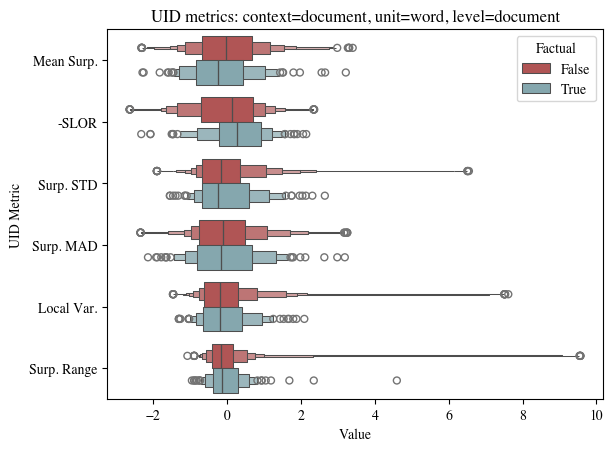

In [23]:
fig, ax = plt.subplots()
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=metrics,
       var_name='UID Metric',
       value_name='Value'
       ),
        hue='factual', x='Value', y='UID Metric', ax=ax, palette=factuality_cmap,
        showfliers=True)
plt.title(f"UID metrics: context={context_lvl}, unit={uid_unit}, level={uid_level}")
handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Factual")
ax.set_yticks(ticks=metrics, labels=metrics_formatted)
fig.savefig("../plots/uid_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

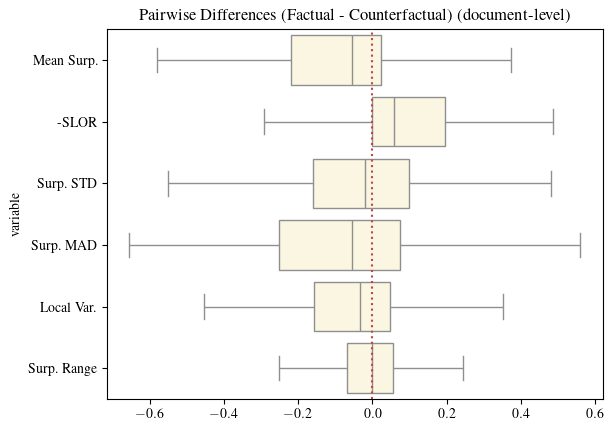

In [ ]:
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion'] + metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion'])), 
            x='value', y='variable', 
            color=conversion_cmap['Both'],
            showfliers=False,
            # inner=None
            )
plt.axvline(x=0, color='#BF4646', linestyle='dotted', zorder=5)
plt.title(f"Pairwise Differences (Factual - Counterfactual) ({uid_level}-level)")
plt.xlabel('')
plt.yticks(ticks=metrics, labels=metrics_formatted)
plt.savefig("../plots/pw_diffs_fact-counterfact" + plot_suffix,
            dpi=200, bbox_inches='tight')

In [ ]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [ ]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   P-value |   Observed abs. diff |
|:------------|----------:|---------------------:|
| Mean Surp.  |      0.16 |                 0.13 |
| -SLOR       |      0    |                 0.27 |
| Surp. STD   |      0.94 |                 0.01 |
| Surp. MAD   |      0.91 |                 0.01 |
| Local Var.  |      0.48 |                 0.07 |
| Surp. Range |      0.95 |                 0.01 |

In [ ]:
cf_repeated = (cf_comparison
               .groupby("doc_name")
               .apply(repeat_factuals)
               .reset_index()
               .sort_values('doc_name'))

In [ ]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_repeated.loc[cf_repeated['factual']]
    cfactuals = cf_repeated.loc[~cf_repeated['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="less"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [ ]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:------------|---------------:|------------------:|--------------:|-----------------:|
| Mean Surp.  |          61.98 |                 0 |         -9.14 |             0    |
| -SLOR       |          25.24 |                 0 |         17.62 |             1    |
| Surp. STD   |        1317.2  |                 0 |         -2.43 |             0.01 |
| Surp. MAD   |         111.38 |                 0 |         -5.55 |             0    |
| Local Var.  |        1740.98 |                 0 |         -5.57 |             0    |
| Surp. Range |        1472.94 |                 0 |         -0.43 |             0.33 |

In [ ]:
cf_comparison

,doc_id,sent_idx,doc_name,context,sentence,raw_surps,raw_uni_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,doc
0,f::GUM_academic_art::-1::og,0,GUM_academic_art,document,Aesthetic Appreciation and Spanish Art:,"[25.87620449066162, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",0.047029,0.591552,1.096493,0.740642,0.561112,0.929111,1.009614,-0.005310,653,True,-1,og,"[Aesthetic Appreciation and Spanish Art:, Insi..."
1,cf::GUM_academic_art::8::a>p,8,GUM_academic_art,document,Do museum labels have an impact on how people ...,"[25.87620449066162, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",0.047029,0.591552,1.096493,0.740642,0.561112,0.929111,1.009614,-0.005310,653,False,8,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
2,cf::GUM_academic_art::11::a>p,11,GUM_academic_art,document,A collaborative pilot project focusing on a un...,"[25.56213665008545, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",0.049926,0.580138,1.094879,0.746115,0.585465,0.929109,1.009082,-0.005373,655,False,11,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
3,cf::GUM_academic_art::16::a>p,16,GUM_academic_art,document,The potential implications of these techniques...,"[25.85675811767578, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",0.059648,0.586341,1.088448,0.742040,0.555769,0.929112,1.007149,-0.005255,655,False,16,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
4,cf::GUM_academic_art::17::a>p,17,GUM_academic_art,document,Established research strengths in Spanish art ...,"[25.812321662902832, 16.13070511817932, 4.7117...","[16.545324187342086, 16.06773611242024, 5.1889...",0.066290,0.551784,1.088628,0.740876,0.537393,0.929110,1.006505,-0.005279,655,False,17,A to P,"[Aesthetic Appreciation and Spanish Art:, Insi..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1539,cf::GUM_whow_skittles::50::a>p,50,GUM_whow_skittles,document,Or they could be scooped by you out when the c...,"[0, 24.463336944580078, 26.201388359069824, 15...","[16.609640474436812, 13.238666171633065, 16.60...",-0.383558,0.369820,-0.322964,-0.083832,-0.587925,-0.343135,0.836369,0.000011,783,False,50,A to P,"[How to Make Skittles Vodka, Three Methods: Si..."
1540,cf::GUM_whow_skittles::51::a>p,51,GUM_whow_skittles,document,Start with small amount of vodka and Skittles ...,"[0, 22.903440475463867, 7.17515754699707, 13.6...","[16.609640474436812, 13.846262573604639, 5.272...",-0.442236,0.416898,-0.360503,-0.119668,-0.593533,-0.305561,0.835731,-0.000032,784,False,51,A to P,"[How to Make Skittles Vodka, Three Methods: Si..."
1541,cf::GUM_whow_skittles::52::a>p,52,GUM_whow_skittles,document,This can be carried by you out with larger amo...,"[0, 24.47439956665039, 26.201388359069824, 15....","[16.609640474436812, 13.238666171633065, 16.60...",-0.418172,0.395790,-0.328768,-0.107019,-0.592008,-0.343135,0.838523,-0.000059,784,False,52,A to P,"[How to Make Skittles Vodka, Three Methods: Si..."
1542,cf::GUM_whow_skittles::53::a>p,53,GUM_whow_skittles,document,A sourness is added by the lime green Skittles...,"[0, 24.44808006286621, 26.201388359069824, 15....","[16.609640474436812, 13.238666171633065, 16.60...",-0.398315,0.380398,-0.314850,-0.094007,-0.591428,-0.343135,0.838921,0.000002,784,False,53,A to P,"[How to Make Skittles Vodka, Three Methods: Si..."


## Graphing Surprisal Contours

In [348]:
from src.uid import *
tokenizer, model, device = load_lm(device='mps')

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 2531.30it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [349]:
def tokens_to_words(tokens):
    return "".join(tokens).split('Ġ')

# def words_to_sentences(row):
#     sentences = row['sentences']
#     sentence_lens = 

In [372]:
# most_different = pw_diffs.sort_values(by='uid_pwd', key=lambda s: np.abs(s), ascending=False).iloc[0]
most_different = pw_diffs.iloc[4]
most_different

doc_name                                          GUM_academic_art
level_1                                                          5
doc_id                               cf::GUM_academic_art::20::p>a
sent_idx                                                        20
context                                                   document
sentence         An interaction between the goals of the observ...
tokens           ['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...
units            [esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...
raw_surps        [19.974449157714844, 16.13070511817932, 4.7117...
raw_uni_surps    [16.609640474436812, 16.06773611242024, 5.1889...
surp_mean                                                -0.029801
surp_slor                                                 0.012015
uid_std                                                   0.004197
uid_mad                                                   0.015821
uid_pwd                                                   0.00

In [373]:
fact_cfact = cf_comparison[(cf_comparison['doc_name'] == most_different['doc_name'])
              & (cf_comparison['sent_idx'].isin([most_different['sent_idx'], 0]))]
fact_cfact['words'] = fact_cfact['doc'].apply(lambda doc: [tokens_to_words(s) for s in doc])
fact_cfact

,doc_id,sent_idx,doc_name,context,sentence,tokens,units,raw_surps,raw_uni_surps,surp_mean,...,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,doc,words
0,f::GUM_academic_art::-1::og,0,GUM_academic_art,document,Aesthetic Appreciation and Spanish Art:,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",0.024139,...,0.582567,0.942241,1.007876,-0.005227,653,True,-1,og,"[Aesthetic Appreciation and Spanish Art:, Insi...","[[Aesthetic Appreciation and Spanish Art:], [I..."
5,cf::GUM_academic_art::20::p>a,20,GUM_academic_art,document,An interaction between the goals of the observ...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",0.053940,...,0.581122,0.942241,1.004221,-0.005288,651,False,20,P to A,"[Aesthetic Appreciation and Spanish Art:, Insi...","[[Aesthetic Appreciation and Spanish Art:], [I..."


In [374]:
fact = fact_cfact.iloc[0].copy(deep=True)
cfact = fact_cfact.iloc[1].copy(deep=True)
cfact['raw_surps'] = cfact['raw_surps'][:366] + [np.nan, np.nan] +  cfact['raw_surps'][366:]

In [375]:
len(fact['raw_surps']), len(cfact['raw_surps'])

(653, 653)

''

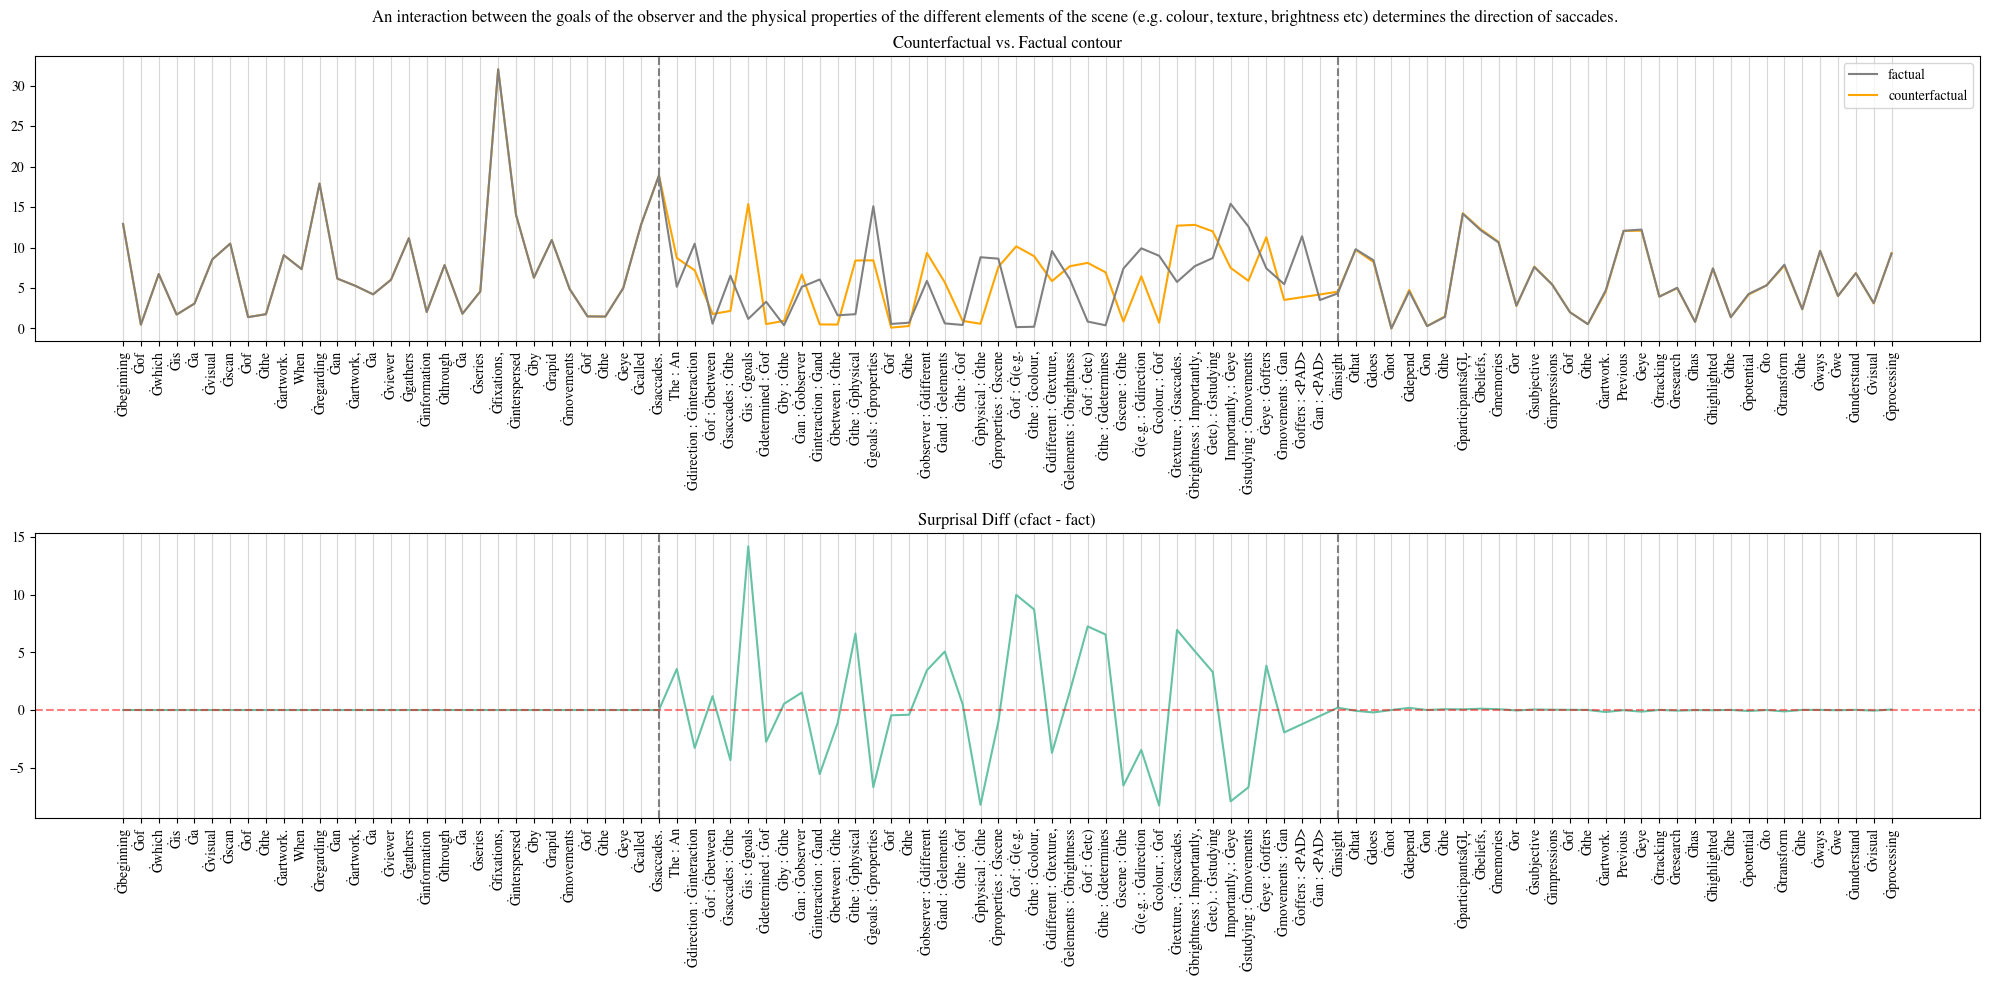

In [376]:
fig, axs = plt.subplots(2, 1, figsize=(20, 10))
length = min(len(fact['raw_surps']), len(cfact['raw_surps']))
diffs = np.array(cfact['raw_surps'][:length]) - np.array(fact['raw_surps'][:length])
start = 300
window = 100
# Surprisal contours
sns.lineplot(x=range(window),y=fact['raw_surps'][start:start + window], label='factual', 
             zorder=3, color='gray', ax=axs[0])
sns.lineplot(x=range(window),y=cfact['raw_surps'][start:start + window], label='counterfactual',
             color='orange', ax=axs[0])

# Getting words
factual_words = np.array(fact['units'])
cfactual_words = np.array(cfact['units'])
cfactual_words = np.insert(cfactual_words, [366, 366], "<PAD>")
fact_cfact_words = [fact_word if fact_word == cfact_word else f"{fact_word} : {cfact_word}"
                    for fact_word,cfact_word in zip(factual_words, cfactual_words)]

# vertical lines + words on x axis
axs[0].axvline(x=330 - start, color='gray', linestyle="--")
axs[0].axvline(x=368 - start, color='gray', linestyle="--")
axs[0].set_title("Counterfactual vs. Factual contour")
axs[0].set_xticks(ticks=range(window), labels=fact_cfact_words[start:start + window], rotation=90)
axs[0].grid(axis='x', alpha=0.5)

sns.lineplot(diffs[start:start+window], ax=axs[1])
axs[1].set_title("Surprisal Diff (cfact - fact)")
axs[1].set_xticks(ticks=range(window), labels=fact_cfact_words[start:start + window], rotation=90)
axs[1].grid(axis='x', alpha=0.5)
axs[1].axvline(x=330 - start, color='gray', linestyle="--")
axs[1].axvline(x=368 - start, color='gray', linestyle="--")
axs[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.suptitle(cfact['sentence'])
plt.tight_layout()
;

Direction of difference is not consistent! Means surprisal isn't just simply increasing

In [377]:
# most_different = pw_diffs.sort_values(by='uid_pwd', key=lambda s: np.abs(s), ascending=False).iloc[0]
most_different = pw_diffs.iloc[3]
most_different

doc_name                                          GUM_academic_art
level_1                                                          4
doc_id                               cf::GUM_academic_art::17::a>p
sent_idx                                                        17
context                                                   document
sentence         Established research strengths in Spanish art ...
tokens           ['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...
units            [esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...
raw_surps        [19.974449157714844, 16.13070511817932, 4.7117...
raw_uni_surps    [16.609640474436812, 16.06773611242024, 5.1889...
surp_mean                                                -0.019319
surp_slor                                                 0.039944
uid_std                                                   0.007488
uid_mad                                                  -0.000747
uid_pwd                                                   0.02

In [378]:
fact_cfact = cf_comparison[(cf_comparison['doc_name'] == most_different['doc_name'])
              & (cf_comparison['sent_idx'].isin([most_different['sent_idx'], 0]))]
fact_cfact['doc'] = fact_cfact['doc'].apply(
    lambda doc: [tokenizer.convert_ids_to_tokens(tokenizer.encode(s)) for s in doc])
fact_cfact['words'] = fact_cfact['doc'].apply(lambda doc: [tokens_to_words(s) for s in doc])
fact_cfact

,doc_id,sent_idx,doc_name,context,sentence,tokens,units,raw_surps,raw_uni_surps,surp_mean,...,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,doc,words
0,f::GUM_academic_art::-1::og,0,GUM_academic_art,document,Aesthetic Appreciation and Spanish Art:,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",0.024139,...,0.582567,0.942241,1.007876,-0.005227,653,True,-1,og,"[[A, esthetic, ĠApp, reciation, Ġand, ĠSpanish...","[[Aesthetic, Appreciation, and, Spanish, Art:]..."
4,cf::GUM_academic_art::17::a>p,17,GUM_academic_art,document,Established research strengths in Spanish art ...,"['esthetic', 'ĠApp', 'reciation', 'Ġand', 'ĠSp...","[esthetic, ĠAppreciation, Ġand, ĠSpanish, ĠArt...","[19.974449157714844, 16.13070511817932, 4.7117...","[16.609640474436812, 16.06773611242024, 5.1889...",0.043458,...,0.558885,0.942240,1.004796,-0.005198,655,False,17,A to P,"[[A, esthetic, ĠApp, reciation, Ġand, ĠSpanish...","[[Aesthetic, Appreciation, and, Spanish, Art:]..."


In [379]:
fact = fact_cfact.iloc[0].copy(deep=True)
cfact = fact_cfact.iloc[1].copy(deep=True)
fact['raw_surps'] = fact['raw_surps'][:265] + [np.nan, np.nan] +  fact['raw_surps'][265:]

In [380]:
print(cfact['sentence'])

Established research strengths in Spanish art history, experimental psychology, digital humanities, and museum studies are brought together by the project to explore, using eye-tracking techniques, aesthetic reactions to digital representations of the individual Zurbarán artworks as well as the significance of the collection as a whole.


In [381]:
len(fact['raw_surps']), len(cfact['raw_surps'])

(655, 655)

''

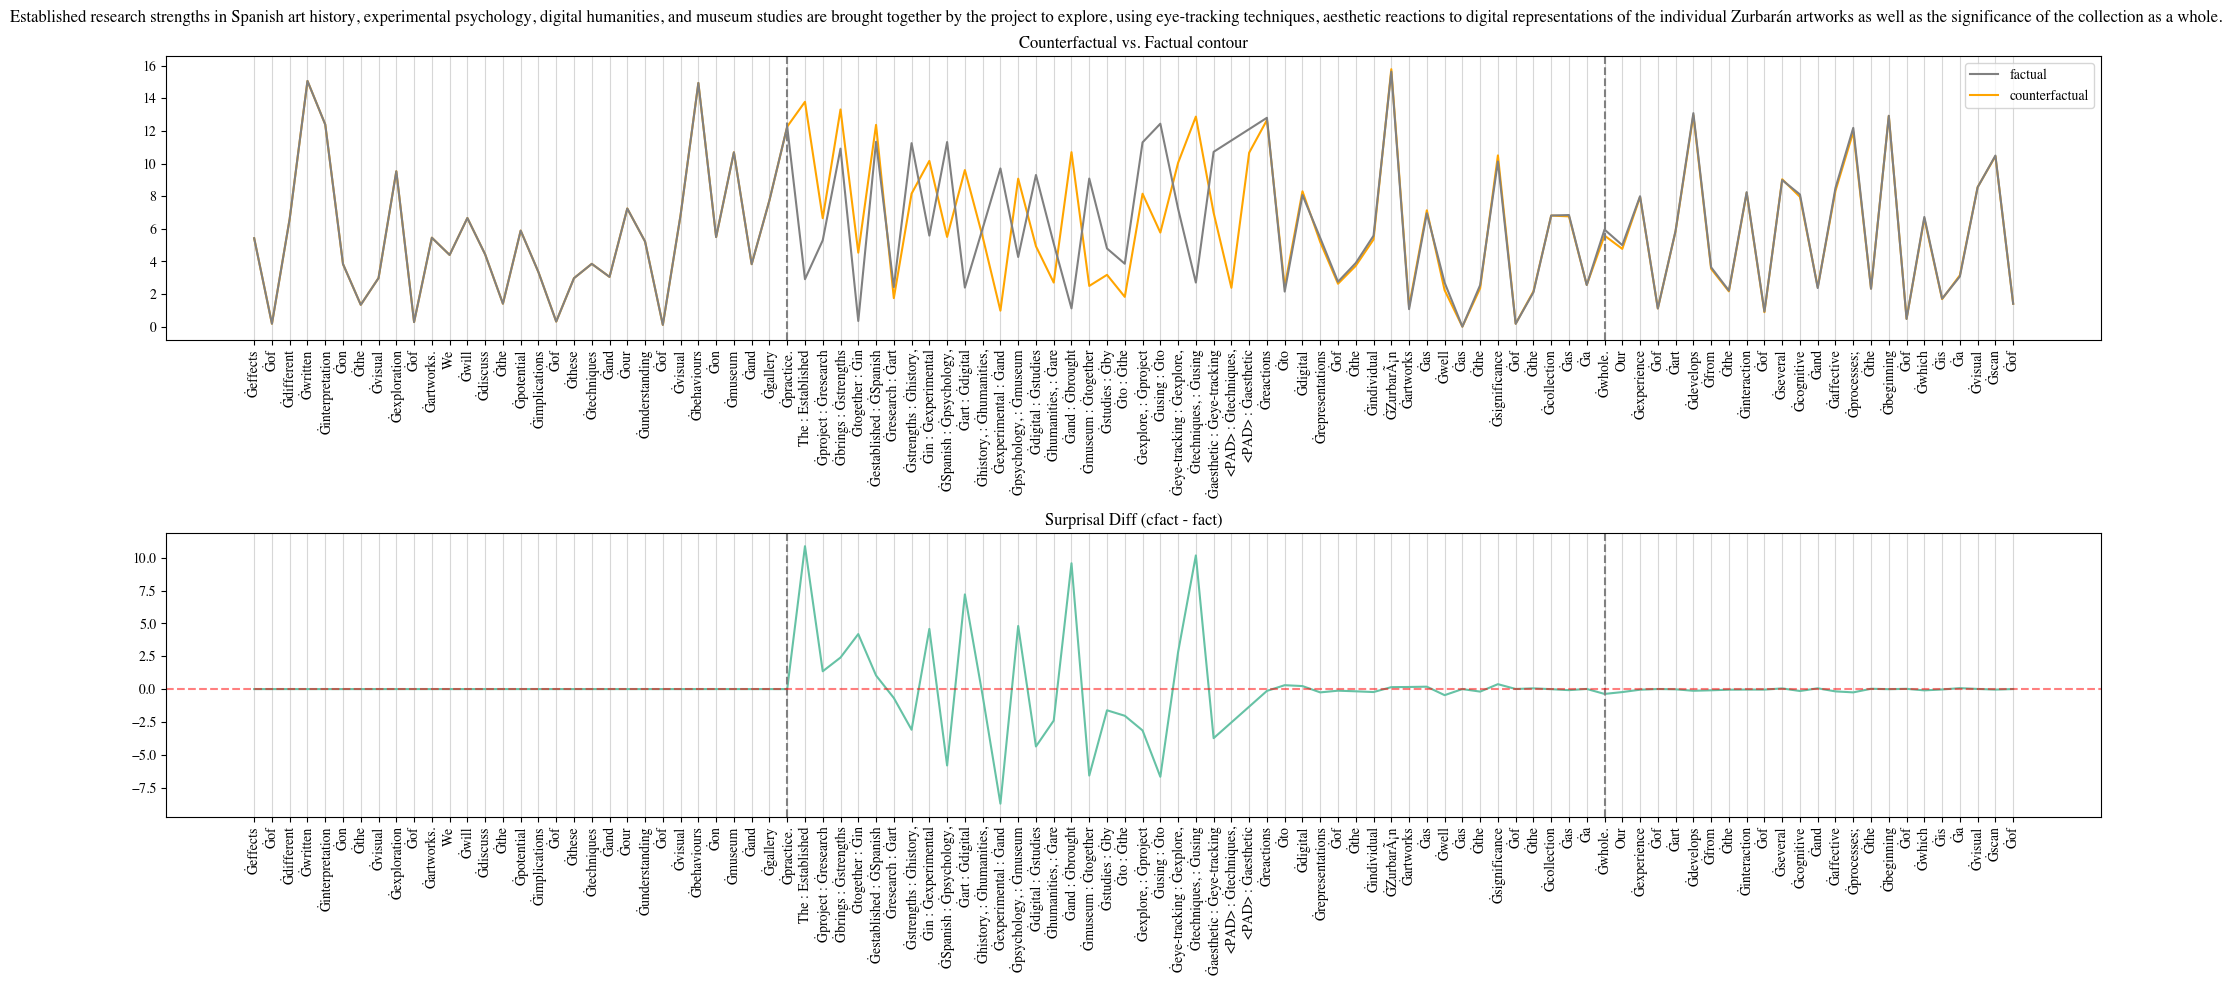

In [384]:
fig, axs = plt.subplots(2, 1, figsize=(20, 10))
length = min(len(fact['raw_surps']), len(cfact['raw_surps']))
diffs = np.array(cfact['raw_surps'][:length]) - np.array(fact['raw_surps'][:length])
start = 210
window = 100
# surprisal contours
sns.lineplot(x=range(window),y=fact['raw_surps'][start:start + window][:length], label='factual', 
             zorder=3, color='gray', ax=axs[0])
sns.lineplot(x=range(window),y=cfact['raw_surps'][start:start + window][:length], label='counterfactual',
             color='orange', ax=axs[0])

# words
factual_words = np.array(fact['units'])[:length]
cfactual_words = np.array(cfact['units'])[:length]
factual_words = np.insert(factual_words, [265, 265], "<PAD>")
fact_cfact_words = np.array([fact_word if fact_word == cfact_word else f"{fact_word} : {cfact_word}"
                    for fact_word,cfact_word in zip(factual_words, cfactual_words)])
# fact_cfact_words += np.arange(length).astype(str)

# axis
axs[0].axvline(x=240-start, color='gray', linestyle="--")
axs[0].axvline(x=286-start, color='gray', linestyle="--")
axs[0].set_title("Counterfactual vs. Factual contour")
axs[0].set_xticks(ticks=range(window), labels=fact_cfact_words[start:start + window], rotation=90)
axs[0].grid(axis='x', alpha=0.5)

sns.lineplot(diffs[start:start+window], ax=axs[1])
axs[1].set_title("Surprisal Diff (cfact - fact)")
axs[1].set_xticks(ticks=range(window), labels=fact_cfact_words[start:start + window], rotation=90)
axs[1].grid(axis='x', alpha=0.5)
axs[1].axvline(x=240 - start, color='gray', linestyle="--")
axs[1].axvline(x=286 - start, color='gray', linestyle="--")
axs[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.suptitle(cfact['sentence'])
plt.tight_layout()
;

In [361]:
" ".join(factual_words[start:start+window])

'Ġeffects Ġof Ġdifferent Ġwritten Ġinterpretation Ġon Ġthe Ġvisual Ġexploration Ġof Ġartworks. We Ġwill Ġdiscuss Ġthe Ġpotential Ġimplications Ġof Ġthese Ġtechniques Ġand Ġour Ġunderstanding Ġof Ġvisual Ġbehaviours Ġon Ġmuseum Ġand Ġgallery Ġpractice. The Ġproject Ġbrings Ġtogether Ġestablished Ġresearch Ġstrengths Ġin ĠSpanish Ġart Ġhistory, Ġexperimental Ġpsychology, Ġdigital Ġhumanities, Ġand Ġmuseum Ġstudies Ġto Ġexplore, Ġusing Ġeye-tracking Ġtechniques, Ġaesthetic <PAD> <PAD> Ġreactions Ġto Ġdigital Ġrepresentations Ġof Ġthe Ġindividual ĠZurbarÃ¡n Ġartworks Ġas Ġwell Ġas Ġthe Ġsignificance Ġof Ġthe Ġcollection Ġas Ġa Ġwhole. Our Ġexperience Ġof Ġart Ġdevelops Ġfrom Ġthe Ġinteraction Ġof Ġseveral Ġcognitive Ġand Ġaffective Ġprocesses; Ġthe Ġbeginning Ġof Ġwhich Ġis Ġa Ġvisual Ġscan Ġof'

In [362]:
" ".join(cfactual_words[start:start+window])

'Ġeffects Ġof Ġdifferent Ġwritten Ġinterpretation Ġon Ġthe Ġvisual Ġexploration Ġof Ġartworks. We Ġwill Ġdiscuss Ġthe Ġpotential Ġimplications Ġof Ġthese Ġtechniques Ġand Ġour Ġunderstanding Ġof Ġvisual Ġbehaviours Ġon Ġmuseum Ġand Ġgallery Ġpractice. Established Ġresearch Ġstrengths Ġin ĠSpanish Ġart Ġhistory, Ġexperimental Ġpsychology, Ġdigital Ġhumanities, Ġand Ġmuseum Ġstudies Ġare Ġbrought Ġtogether Ġby Ġthe Ġproject Ġto Ġexplore, Ġusing Ġeye-tracking Ġtechniques, Ġaesthetic Ġreactions Ġto Ġdigital Ġrepresentations Ġof Ġthe Ġindividual ĠZurbarÃ¡n Ġartworks Ġas Ġwell Ġas Ġthe Ġsignificance Ġof Ġthe Ġcollection Ġas Ġa Ġwhole. Our Ġexperience Ġof Ġart Ġdevelops Ġfrom Ġthe Ġinteraction Ġof Ġseveral Ġcognitive Ġand Ġaffective Ġprocesses; Ġthe Ġbeginning Ġof Ġwhich Ġis Ġa Ġvisual Ġscan Ġof'

TEST

In [363]:
test_fact = "pilot study was to assess the effects of different written interpretation on the visual exploration of artworks. We will discuss the potential implications of these techniques and our understanding of visual behaviours on museum and gallery practice. The project brings together established research strengths in Spanish art history, experimental psychology, digital humanities, and museum studies to explore, using eye-tracking techniques, aesthetic reactions to digital representations of the individual ZurbarÃ¡n artworks as well as the significance of the collection as a whole."
test_cfact = "pilot study was to assess the effects of different written interpretation on the visual exploration of artworks. We will discuss the potential implications of these techniques and our understanding of visual behaviours on museum and gallery practice. Established research strengths in Spanish art history, experimental psychology, digital humanities, and museum studies are brought together by the project to explore, using eye-tracking techniques, aesthetic reactions to digital representations of the individual ZurbarÃ¡n artworks as well as the significance of the collection as a whole."
test_fact_ids = torch.tensor([tokenizer.encode(test_fact)], device=device)
test_cfact_ids = torch.tensor([tokenizer.encode(test_cfact)], device=device)
output_surps = []
for input_ids in [test_fact_ids, test_cfact_ids]:
    print(input_ids.size())
    with torch.no_grad():
        logits = model(input_ids).logits
        log_probs = torch.log_softmax(logits, dim=-1)
    surprisals = []
    print(log_probs.size())
    for i in range(input_ids.size(1)):
        token_id = input_ids[0, i]
        lp = log_probs[0, i - 1, token_id]
        surprisal = (-lp / math.log(2)).item()
        surprisals.append(surprisal)
    print("Done")
    output_surps.append(surprisals)

torch.Size([1, 99])
torch.Size([1, 99, 50257])
Done
torch.Size([1, 102])
torch.Size([1, 102, 50257])
Done


In [364]:
test = pd.DataFrame({
    'fact_surps': word_surps[0][0][:55] + [np.nan] * 2 + word_surps[0][0][55:],
    'cfact_surps': word_surps[1][0],
    'fact_words': word_surps[0][1][:55] + ["<PAD>"] * 2 + word_surps[0][1][55:],
    'cfact_words': word_surps[1][1]
})
test

,fact_surps,cfact_surps,fact_words,cfact_words
0,37.624010,38.395491,pilot,pilot
1,14.018075,14.018075,Ġstudy,Ġstudy
2,6.495533,6.495533,Ġwas,Ġwas
3,8.249424,8.249424,Ġto,Ġto
4,4.378479,4.378479,Ġassess,Ġassess
...,...,...,...,...
78,2.067571,2.088317,Ġthe,Ġthe
79,9.955218,9.845294,Ġcollection,Ġcollection
80,5.665833,5.740946,Ġas,Ġas
81,1.128904,1.191052,Ġa,Ġa


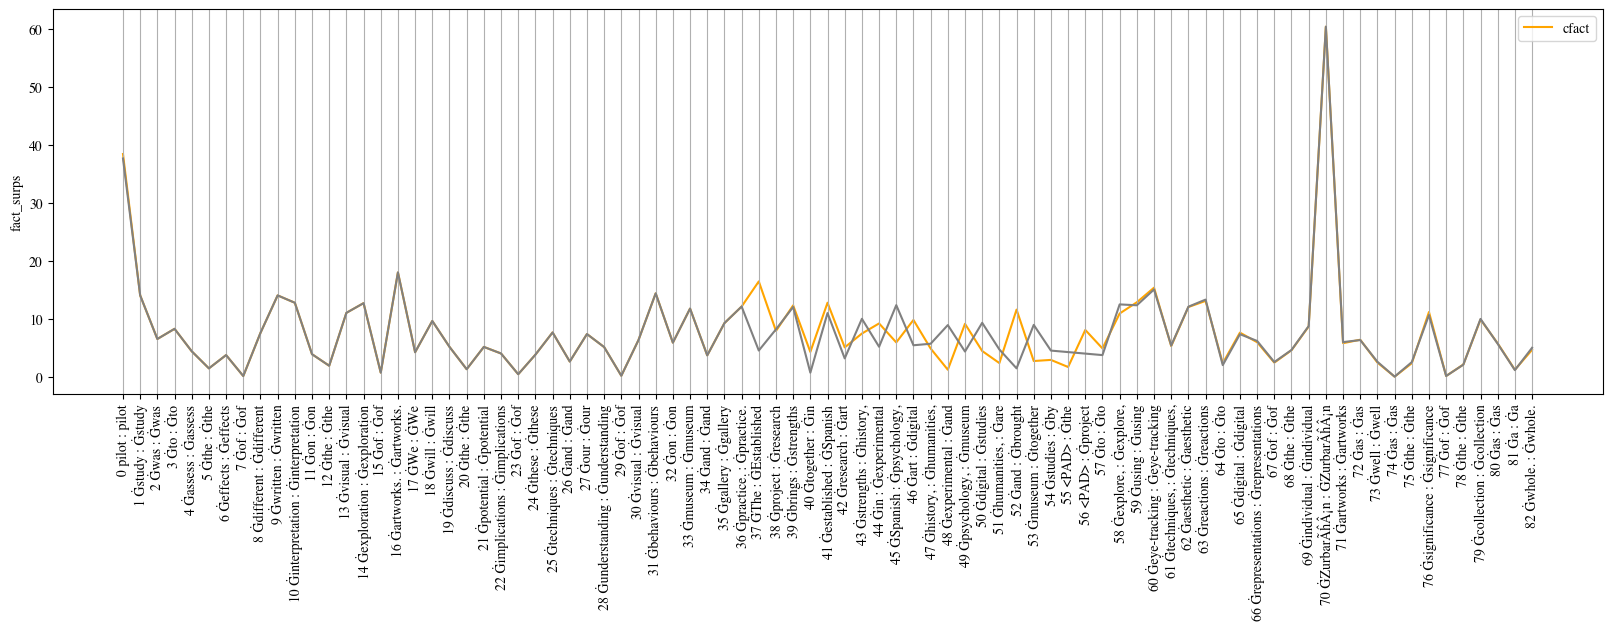

In [365]:
plt.subplots(figsize=(20, 5))
sns.lineplot(test['fact_surps'], zorder=2, color='gray')
sns.lineplot(test['cfact_surps'], zorder=0, label='cfact', color='orange')
tokens = test.index.astype(str) + " " + test['fact_words'] + " : " + test['cfact_words']
plt.xticks(ticks=range(test.shape[0]), labels=tokens, rotation=90)
plt.grid(axis='x');

In [366]:
tokenizer.convert_ids_to_tokens(test_cfact_tokens[0]), tokenizer.convert_ids_to_tokens(test_fact_tokens[0])

(['p',
  'ilot',
  'Ġstudy',
  'Ġwas',
  'Ġto',
  'Ġassess',
  'Ġthe',
  'Ġeffects',
  'Ġof',
  'Ġdifferent',
  'Ġwritten',
  'Ġinterpretation',
  'Ġon',
  'Ġthe',
  'Ġvisual',
  'Ġexploration',
  'Ġof',
  'Ġart',
  'works',
  '.',
  'ĠWe',
  'Ġwill',
  'Ġdiscuss',
  'Ġthe',
  'Ġpotential',
  'Ġimplications',
  'Ġof',
  'Ġthese',
  'Ġtechniques',
  'Ġand',
  'Ġour',
  'Ġunderstanding',
  'Ġof',
  'Ġvisual',
  'Ġbehaviours',
  'Ġon',
  'Ġmuseum',
  'Ġand',
  'Ġgallery',
  'Ġpractice',
  '.',
  'ĠEst',
  'ablished',
  'Ġresearch',
  'Ġstrengths',
  'Ġin',
  'ĠSpanish',
  'Ġart',
  'Ġhistory',
  ',',
  'Ġexperimental',
  'Ġpsychology',
  ',',
  'Ġdigital',
  'Ġhumanities',
  ',',
  'Ġand',
  'Ġmuseum',
  'Ġstudies',
  'Ġare',
  'Ġbrought',
  'Ġtogether',
  'Ġby',
  'Ġthe',
  'Ġproject',
  'Ġto',
  'Ġexplore',
  ',',
  'Ġusing',
  'Ġeye',
  '-',
  'tracking',
  'Ġtechniques',
  ',',
  'Ġaesthetic',
  'Ġreactions',
  'Ġto',
  'Ġdigital',
  'Ġrepresentations',
  'Ġof',
  'Ġthe',
  'Ġindividu